### Co-expression Network Analysis

Build a gene co-expression network to identify modules of co-regulated genes and hub genes that may serve as regulatory drivers in ovarian cancer.

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import networkx as nx
from scipy.stats import spearmanr

sns.set_style("whitegrid")
np.random.seed(42)

# Load processed expression data
expr = pd.read_csv('../data/processed/expression_cleaned.csv', index_col=0)
clusters = pd.read_csv('../data/processed/cluster_assignments.csv')
de_results = pd.read_csv('../data/processed/de_cluster2_vs_others.csv')

# Log-transform
expr_log = np.log2(expr + 1)

print(f"Expression: {expr_log.shape}")
print(f"Cluster assignments: {clusters.shape}")

Expression: (19062, 300)
Cluster assignments: (300, 8)


### Selecting genes for the network

Building a network on all 19,062 genes would be:
- Computationally expensive (correlation matrix = 19062 × 19062 = 363M values)
- Mostly noise (correlations between unrelated genes)
- Hard to interpret

We focus on the **top 1,000 most variable genes** for speed and interpretability in this prototype.

In [2]:
N_GENES = 1000

# Compute variance and select top genes
gene_var = expr_log.var(axis=1)
top_genes = gene_var.sort_values(ascending=False).head(N_GENES).index.tolist()

expr_subset = expr_log.loc[top_genes]
print(f"Selected {N_GENES} most variable genes")
print(f"Expression matrix: {expr_subset.shape}")

Selected 1000 most variable genes
Expression matrix: (1000, 300)


### Computing gene-gene correlations

We compute the **Spearman correlation** between every pair of genes across patients. 
Spearman is preferred over Pearson here because:
- It handles non-linear relationships
- It's robust to outliers (which are common in expression data)

The result is a 1000×1000 correlation matrix.

Computing Spearman correlation matrix
Correlation matrix shape: (1000, 1000)

Diagonal values (should all be 1.0): [1. 1. 1. 1. 1.]
Correlation range: [-0.648, 1.000]


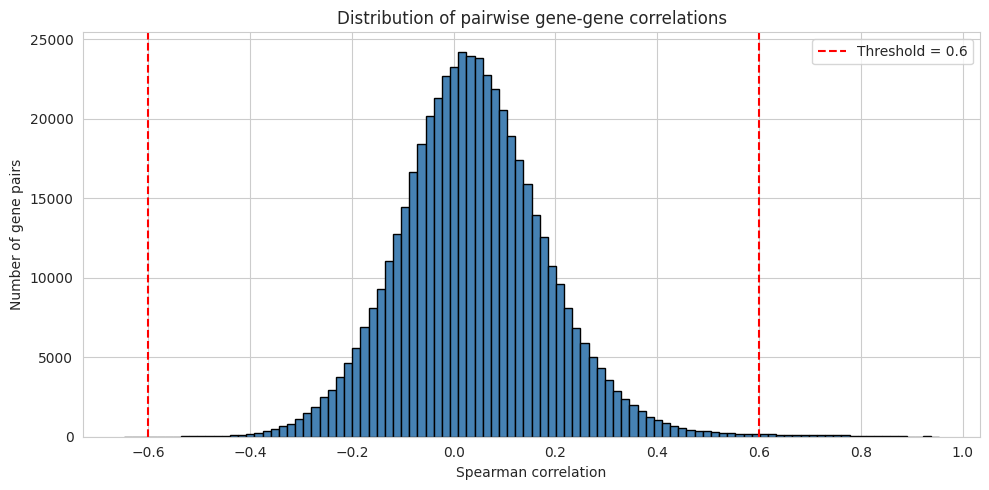


Total gene pairs: 499,500
Pairs with |correlation| > 0.6: 1,618 (0.32%)


In [3]:
print("Computing Spearman correlation matrix")

# Transpose so rows = samples, columns = genes (correlations are computed between columns)
expr_T = expr_subset.T

# pandas spearman correlation
corr_matrix = expr_T.corr(method='spearman')
print(f"Correlation matrix shape: {corr_matrix.shape}")

# Sanity checks
print(f"\nDiagonal values (should all be 1.0): {np.diag(corr_matrix)[:5]}")
print(f"Correlation range: [{corr_matrix.values.min():.3f}, {corr_matrix.values.max():.3f}]")

# Visualize correlation distribution
fig, ax = plt.subplots(figsize=(10, 5))
# Get upper triangle (excluding diagonal) to avoid duplicates
upper_tri = corr_matrix.values[np.triu_indices(N_GENES, k=1)]
ax.hist(upper_tri, bins=100, color='steelblue', edgecolor='black')
ax.set_xlabel('Spearman correlation')
ax.set_ylabel('Number of gene pairs')
ax.set_title('Distribution of pairwise gene-gene correlations')
ax.axvline(0.6, color='red', linestyle='--', label='Threshold = 0.6')
ax.axvline(-0.6, color='red', linestyle='--')
ax.legend()
plt.tight_layout()
plt.savefig('../figures/12_correlation_distribution.png', dpi=150, bbox_inches='tight')
plt.show()

# How many pairs exceed our threshold?
n_strong = (np.abs(upper_tri) > 0.6).sum()
total_pairs = len(upper_tri)
print(f"\nTotal gene pairs: {total_pairs:,}")
print(f"Pairs with |correlation| > 0.6: {n_strong:,} ({100*n_strong/total_pairs:.2f}%)")

### Constructing the network

We construct an undirected graph where:
- **Nodes** = genes
- **Edges** = pairs of genes with |correlation| > 0.6
- **Edge weights** = absolute correlation value

Genes that don't have any strong correlations will be isolated nodes, we'll filter those out to focus on the connected structure.

In [4]:
THRESHOLD = 0.6

# Build the network from the correlation matrix
print(f"Building network with |correlation| > {THRESHOLD}...")

G = nx.Graph()

# Add edges where correlation exceeds threshold
n_edges_added = 0
for i in range(N_GENES):
    for j in range(i + 1, N_GENES):
        corr = corr_matrix.iloc[i, j]
        if abs(corr) > THRESHOLD:
            gene_i = corr_matrix.index[i]
            gene_j = corr_matrix.columns[j]
            G.add_edge(gene_i, gene_j, weight=abs(corr), correlation=corr)
            n_edges_added += 1

print(f"Edges added: {n_edges_added:,}")
print(f"Network has {G.number_of_nodes():,} nodes (genes with at least one edge)")
print(f"Network has {G.number_of_edges():,} edges")
print(f"Isolated genes (filtered out): {N_GENES - G.number_of_nodes()}")

# Network statistics
n_components = nx.number_connected_components(G)
largest_cc = max(nx.connected_components(G), key=len)
print(f"\nConnected components: {n_components}")
print(f"Size of largest component: {len(largest_cc)} genes")
print(f"Average degree: {sum(dict(G.degree()).values()) / G.number_of_nodes():.2f}")

Building network with |correlation| > 0.6...
Edges added: 1,618
Network has 267 nodes (genes with at least one edge)
Network has 1,618 edges
Isolated genes (filtered out): 733

Connected components: 38
Size of largest component: 132 genes
Average degree: 12.12


### Identifying network modules (communities)

Modules are densely connected groups of genes that are likely to share biological function. We use the **Louvain algorithm**, a fast, popular community detection 
method to find these modules.

Intuition: genes in the same module are more correlated with each other than with genes in other modules.

In [5]:
# Use the Louvain algorithm via networkx
import networkx.algorithms.community as nx_comm

# Run community detection on the largest connected component
G_main = G.subgraph(largest_cc).copy()

print(f"Running Louvain on largest component ({G_main.number_of_nodes()} nodes)...")

communities = nx_comm.louvain_communities(G_main, weight='weight', seed=42)

# Sort by size
communities = sorted(communities, key=len, reverse=True)
print(f"Found {len(communities)} communities")

# Print sizes
print("\nCommunity sizes:")
for i, comm in enumerate(communities[:10]):
    print(f"  Module {i+1}: {len(comm)} genes")

# Create a gene-to-module mapping
gene_to_module = {}
for module_id, members in enumerate(communities):
    for gene in members:
        gene_to_module[gene] = module_id

# Print examples from the largest modules
print("\n--- Top 5 modules: example genes ---")
for i, comm in enumerate(communities[:5]):
    sample_genes = list(comm)[:10]
    print(f"\nModule {i+1} ({len(comm)} genes): {sample_genes}")

Running Louvain on largest component (132 nodes)...
Found 6 communities

Community sizes:
  Module 1: 52 genes
  Module 2: 36 genes
  Module 3: 30 genes
  Module 4: 7 genes
  Module 5: 4 genes
  Module 6: 3 genes

--- Top 5 modules: example genes ---

Module 1 (52 genes): ['COL11A1', 'PLN', 'BCHE', 'OMD', 'SFRP2', 'ITGBL1', 'NTM', 'ALPK2', 'SCG2', 'POSTN']

Module 2 (36 genes): ['MMP9', 'HLA-DRB5', 'CXCR2P1', 'ZNF683', 'CXCL13', 'MGC29506', 'CD79A', 'CD1E', 'MMP12', 'KIAA0125']

Module 3 (30 genes): ['DLK1', 'PTPN5', 'GATA4', 'ATRNL1', 'PLCXD3', 'CASR', 'SCUBE1', 'C7', 'FOXL2', 'DHRS2']

Module 4 (7 genes): ['FMO2', 'NNMT', 'SAA1', 'VNN3', 'SAA2', 'PDZK1IP1', 'LCN2']

Module 5 (4 genes): ['FABP4', 'ADH1B', 'ADIPOQ', 'CCL21']


In [6]:
# Hub genes = genes with the most connections in the network
# These are often important regulatory or central biological genes

degree_dict = dict(G_main.degree())
degree_series = pd.Series(degree_dict).sort_values(ascending=False)

# Annotate with module assignment
hub_df = pd.DataFrame({
    'gene': degree_series.index,
    'degree': degree_series.values,
    'module': [gene_to_module.get(g, -1) for g in degree_series.index]
})

# Top hubs overall
print("Top 20 hub genes (most connected):")
print(hub_df.head(20).to_string(index=False))

# Save
hub_df.to_csv('../data/processed/hub_genes.csv', index=False)

Top 20 hub genes (most connected):
   gene  degree  module
    LUM      49       0
    FAP      48       0
  POSTN      45       0
  PRRX1      45       0
  SFRP2      45       0
  THBS2      44       0
COL11A1      43       0
 ADAM12      42       0
  INHBA      42       0
    NTM      41       0
   ASPN      41       0
  ALPK2      40       0
 LRRC15      40       0
    OMD      40       0
 ITGBL1      40       0
  MMP11      39       0
   EPYC      38       0
  SVEP1      38       0
COL10A1      38       0
   GJB2      36       0


### Visualizing the network

We visualize the network with nodes colored by module and sized by degree.

Computing network layout (this may take a moment)...


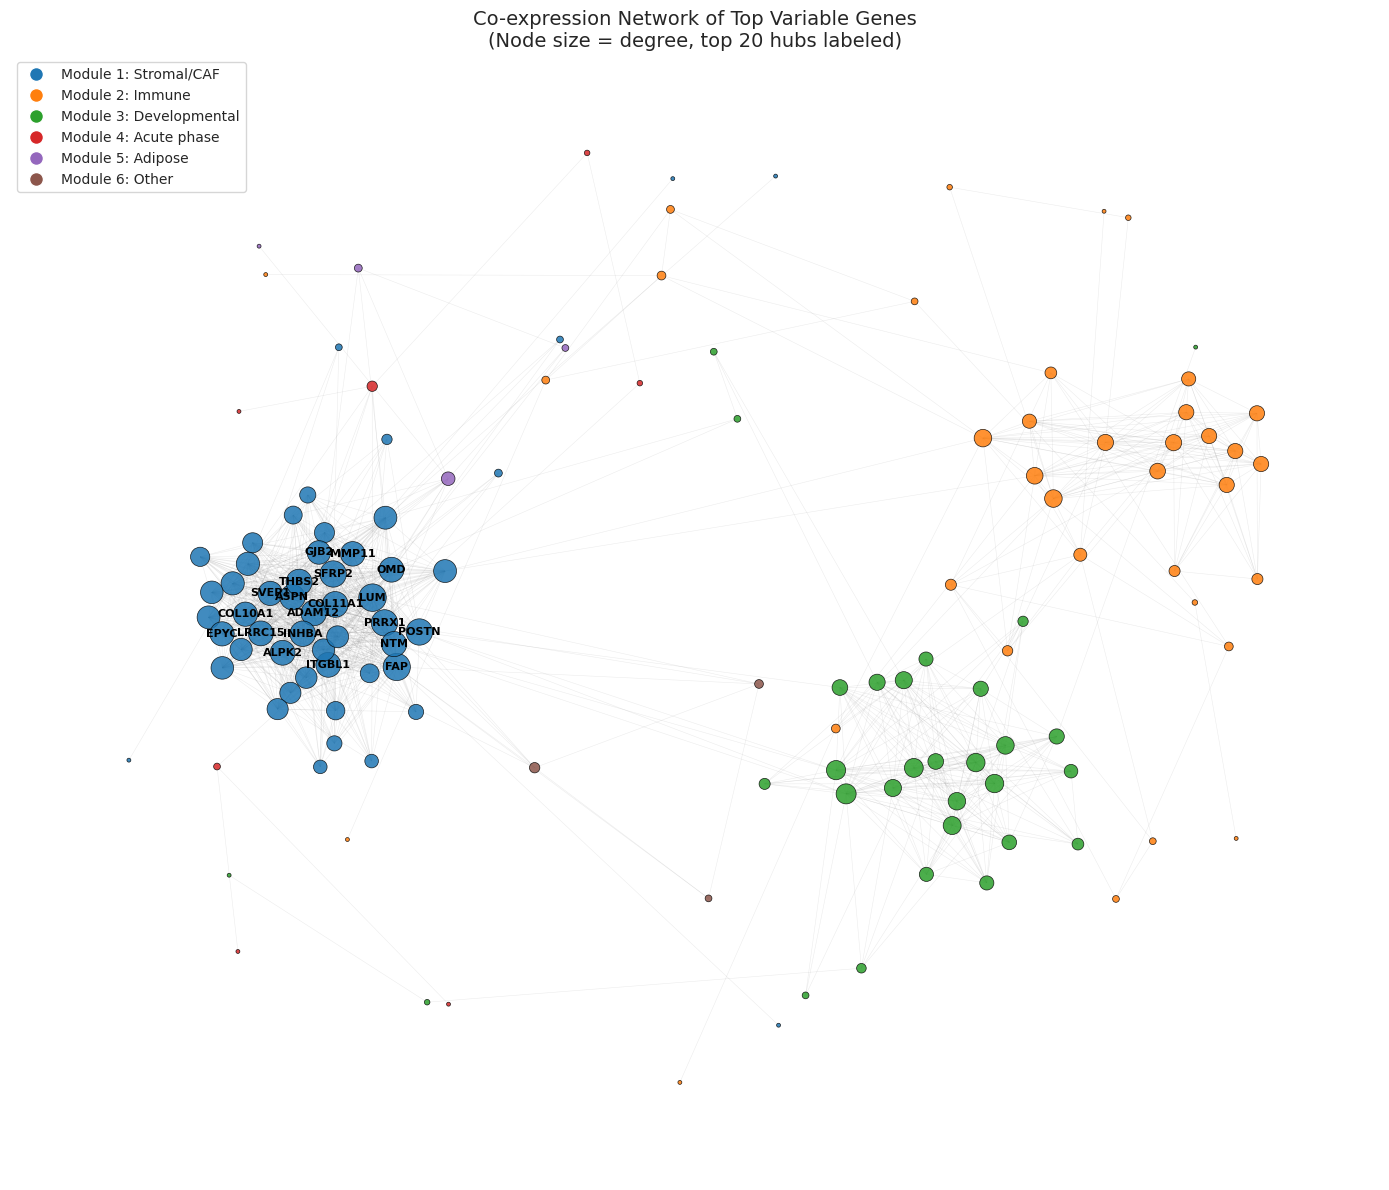

In [7]:
import matplotlib.cm as cm

# Layout - use spring layout for nice visualization
print("Computing network layout (this may take a moment)...")
pos = nx.spring_layout(G_main, k=0.5, iterations=50, seed=42, weight='weight')

fig, ax = plt.subplots(figsize=(14, 12))

# Color nodes by module
module_colors = cm.tab10(np.linspace(0, 1, 10))
node_colors = []
for node in G_main.nodes():
    module_id = gene_to_module.get(node, -1)
    if module_id < len(module_colors):
        node_colors.append(module_colors[module_id])
    else:
        node_colors.append('lightgray')

# Size nodes by degree
degrees = dict(G_main.degree())
node_sizes = [min(degrees[n] * 8, 400) for n in G_main.nodes()]

# Draw edges first (translucent)
nx.draw_networkx_edges(G_main, pos, alpha=0.15, width=0.4, edge_color='gray')

# Draw nodes
nx.draw_networkx_nodes(G_main, pos, node_color=node_colors, node_size=node_sizes,
                        alpha=0.85, edgecolors='black', linewidths=0.5)

# Label only the top hub genes (top 20 by degree)
top_hub_genes = sorted(degrees.items(), key=lambda x: -x[1])[:20]
labels = {gene: gene for gene, _ in top_hub_genes}
nx.draw_networkx_labels(G_main, pos, labels, font_size=8, font_weight='bold')

# Module legend
module_names = [
    'Module 1: Stromal/CAF',
    'Module 2: Immune',
    'Module 3: Developmental',
    'Module 4: Acute phase',
    'Module 5: Adipose',
    'Module 6: Other',
]
legend_handles = [
    plt.Line2D([0], [0], marker='o', color='w', markerfacecolor=module_colors[i],
               markersize=10, label=module_names[i])
    for i in range(min(6, len(communities)))
]
ax.legend(handles=legend_handles, loc='upper left', fontsize=10)

ax.set_title('Co-expression Network of Top Variable Genes\n(Node size = degree, top 20 hubs labeled)',
             fontsize=14)
ax.axis('off')

plt.tight_layout()
plt.savefig('../figures/13_coexpression_network.png', dpi=150, bbox_inches='tight')
plt.show()

### Linking modules to clinical outcomes

For each module, we compute a **module score** per patient (the average expression of all genes in the module). We then test whether these scores associate with survival.

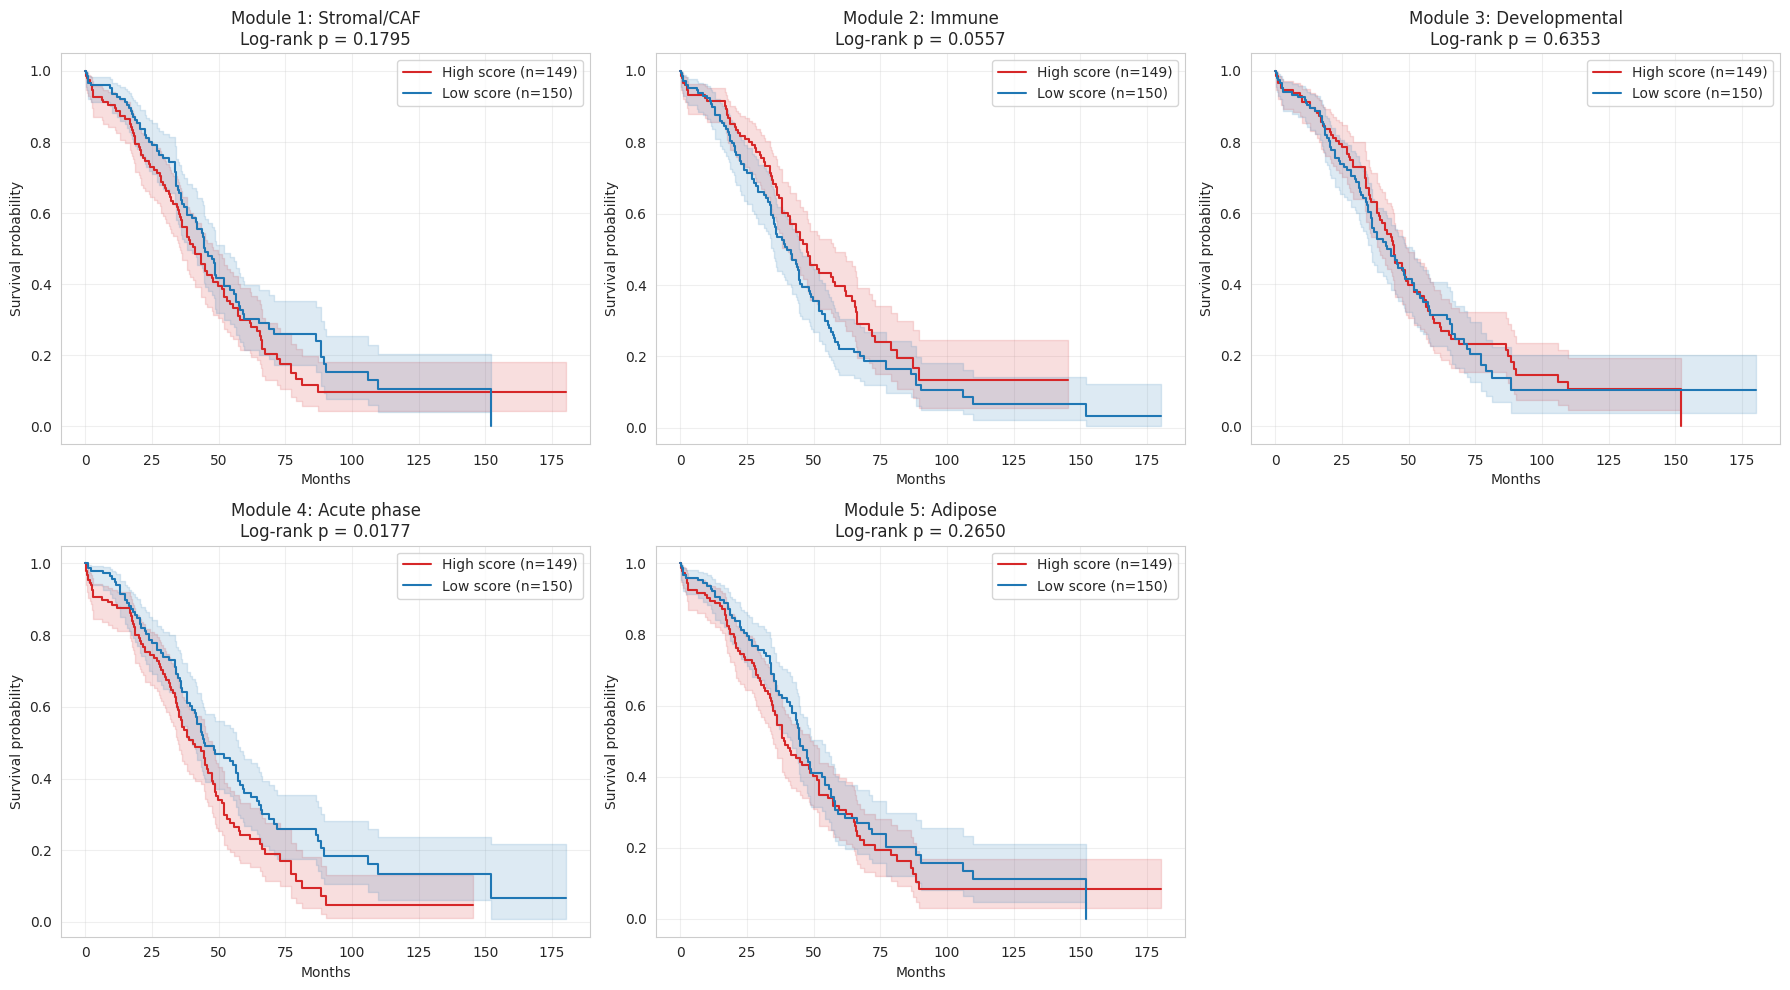


--- Module survival association (median split) ---
  module          name  p_value  n_genes
Module 1   Stromal/CAF 0.179501       52
Module 2        Immune 0.055701       36
Module 3 Developmental 0.635289       30
Module 4   Acute phase 0.017749        7
Module 5       Adipose 0.264955        4


In [8]:
from lifelines import KaplanMeierFitter
from lifelines.statistics import logrank_test

# Load aligned clinical data
clinical = pd.read_csv('../data/processed/clinical_aligned.csv')

# Compute module scores per sample
module_scores = pd.DataFrame(index=expr_log.columns)
for i, module_genes in enumerate(communities[:5]):  # Top 5 modules
    module_genes_in_data = [g for g in module_genes if g in expr_log.index]
    if len(module_genes_in_data) >= 3:
        # Z-score each gene first, then average
        module_expr = expr_log.loc[module_genes_in_data]
        module_zscored = (module_expr.sub(module_expr.mean(axis=1), axis=0)
                          .div(module_expr.std(axis=1), axis=0))
        module_scores[f'module_{i+1}'] = module_zscored.mean(axis=0)

# Map sample IDs to patient IDs
module_scores.index = ['-'.join(s.split('-')[:3]) for s in module_scores.index]
module_scores.index.name = 'PATIENT_ID'
module_scores = module_scores.reset_index()

# Merge with clinical data
merged = clinical.merge(module_scores, on='PATIENT_ID')
merged['OS_EVENT'] = merged['OS_STATUS'].map({'1:DECEASED': 1, '0:LIVING': 0})
merged = merged.dropna(subset=['OS_MONTHS', 'OS_EVENT'])

# For each module, split patients into high/low score (median split) and test survival
fig, axes = plt.subplots(2, 3, figsize=(18, 10))
axes = axes.flatten()

module_names_short = ['Stromal/CAF', 'Immune', 'Developmental', 'Acute phase', 'Adipose']
module_results = []

for i in range(5):
    col = f'module_{i+1}'
    if col not in merged.columns:
        continue
    
    median_score = merged[col].median()
    high_mask = merged[col] > median_score
    low_mask = ~high_mask
    
    # Log-rank test
    lr = logrank_test(
        durations_A=merged.loc[high_mask, 'OS_MONTHS'],
        durations_B=merged.loc[low_mask, 'OS_MONTHS'],
        event_observed_A=merged.loc[high_mask, 'OS_EVENT'],
        event_observed_B=merged.loc[low_mask, 'OS_EVENT']
    )
    
    # Plot
    ax = axes[i]
    kmf = KaplanMeierFitter()
    
    kmf.fit(merged.loc[high_mask, 'OS_MONTHS'], merged.loc[high_mask, 'OS_EVENT'],
            label=f'High score (n={high_mask.sum()})')
    kmf.plot_survival_function(ax=ax, color='#d62728', ci_alpha=0.15)
    
    kmf.fit(merged.loc[low_mask, 'OS_MONTHS'], merged.loc[low_mask, 'OS_EVENT'],
            label=f'Low score (n={low_mask.sum()})')
    kmf.plot_survival_function(ax=ax, color='#1f77b4', ci_alpha=0.15)
    
    ax.set_title(f'Module {i+1}: {module_names_short[i]}\nLog-rank p = {lr.p_value:.4f}')
    ax.set_xlabel('Months')
    ax.set_ylabel('Survival probability')
    ax.grid(True, alpha=0.3)
    
    module_results.append({
        'module': f'Module {i+1}',
        'name': module_names_short[i],
        'p_value': lr.p_value,
        'n_genes': len(communities[i])
    })

# Hide the unused subplot
axes[5].axis('off')

plt.tight_layout()
plt.savefig('../figures/14_module_survival.png', dpi=150, bbox_inches='tight')
plt.show()

# Summary table
print("\n--- Module survival association (median split) ---")
print(pd.DataFrame(module_results).to_string(index=False))

### Saving network module assignments

We save:
- The module assignment per gene (for downstream analysis or sharing)
- The hub genes table
- A summary of network statistics

In [9]:
# Build a comprehensive gene-to-module dataframe
module_df_rows = []
for module_id, genes in enumerate(communities):
    for gene in genes:
        module_df_rows.append({
            'gene': gene,
            'module': module_id + 1,  # 1-indexed for readability
            'module_size': len(genes),
            'degree': G_main.degree(gene)
        })

module_df = pd.DataFrame(module_df_rows)
module_df = module_df.sort_values(['module', 'degree'], ascending=[True, False])

print(f"Saved module assignments for {len(module_df)} genes across {len(communities)} modules")
module_df.to_csv('../data/processed/gene_module_assignments.csv', index=False)

# Also save the network as an edge list
edge_list = []
for u, v, data in G_main.edges(data=True):
    edge_list.append({
        'gene_a': u,
        'gene_b': v,
        'correlation': data['correlation'],
        'weight': data['weight']
    })

edge_df = pd.DataFrame(edge_list)
edge_df.to_csv('../data/processed/network_edges.csv', index=False)
print(f"Saved {len(edge_df)} network edges")

# Save module-level summary
module_summary = pd.DataFrame({
    'module': [f'Module {i+1}' for i in range(len(communities))],
    'name': ['Stromal/CAF', 'Immune', 'Developmental', 'Acute phase', 'Adipose', 'Other'][:len(communities)],
    'n_genes': [len(c) for c in communities],
    'top_hubs': [
        ', '.join(
            sorted(c, key=lambda g: G_main.degree(g) if g in G_main else 0, reverse=True)[:5]
        ) for c in communities
    ]
})
module_summary.to_csv('../data/processed/module_summary.csv', index=False)
print("\nModule summary:")
print(module_summary.to_string(index=False))

Saved module assignments for 132 genes across 6 modules
Saved 1131 network edges

Module summary:
  module          name  n_genes                           top_hubs
Module 1   Stromal/CAF       52      LUM, FAP, SFRP2, POSTN, PRRX1
Module 2        Immune       36  CXCL9, IL21R, GZMK, PLA2G2D, IRF4
Module 3 Developmental       30 COLEC11, STAR, ARX, FOXL2, C3orf72
Module 4   Acute phase        7       NNMT, LCN2, SAA1, SAA2, FMO2
Module 5       Adipose        4        FABP4, CCL21, ADH1B, ADIPOQ
Module 6         Other        3                CPA3, TPSB2, TPSAB1
